The code runs on the IRIS data set, carrying out a QPCA however this is not correct. 
For this to be a accurate represantion and results to be correct the classical data has to be prepared into a quantum state. 
to then be mapped onto a quantum register. 


Also Hardman gate for superpposition, however we need a quantum Fourier transform. 

The QPE algotithm is way more complicated than what is carried out below, learn from this textbook and build on it : https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb


In [ ]:
#PIris dataset.

from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import numpy as np

# Load the iris dataset as a pandas DataFrame
iris = load_iris()

# Convert the dataset to a pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column to the DataFrame, using target_names to map integers to class labels
iris_df['target'] = pd.Categorical.from_codes(iris.target, iris.target_names)


# Select only numerical features
iris_features = iris_df.iloc[:, :-1]  # Exclude target column

data = iris_features

# Compute the covariance matrix transpose so its features not samples 4x4
cov_matrix = np.cov(iris_features.T)

# Convert to DataFrame for readability
cov_df = pd.DataFrame(cov_matrix, index=iris.feature_names, columns=iris.feature_names)

# Display the covariance matrix
print(cov_df)



ModuleNotFoundError: No module named 'sklearn'

In [1]:
from qiskit.circuit.library import ZZFeatureMap
import qiskit
from qiskit import QuantumCircuit
#from qiskit.utils import QuantumInstance deprecated 
from qiskit.compiler import transpile
from qiskit.primitives import Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt



ModuleNotFoundError: No module named 'qiskit_aer'

In [2]:
#Encode the covariance matrix into a quantum state 
#this is inccorect papers say you have to do proper state encoding  and then applying a procedure like quantum phase estimation.
def encode_cov_matrix(cov_matrix):
    """Encode covariance matrix into a quantum state"""
    num_features = cov_matrix.shape[0]  # Number of features
    
    # Use a ZZFeatureMap for encoding
    feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2)  # reps=2 is a good starting point
    qc = QuantumCircuit(num_features)
    # Apply feature map
    qc.append(feature_map, range(num_features))
    
    return qc
encode_cov_matrix(cov_df)


def quantum_pca(data):
    """Quantum PCA using Qiskit & Quantum Phase Estimation (QPE)"""
    # Normalize the data
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)  # Standardization
    # Compute covariance matrix
    cov_matrix = np.cov(data.T)
    
    # Encode covariance matrix into quantum state using feature map
    qc = encode_cov_matrix(cov_matrix)

    # Define the number of qubits
    n_qubits = 3 # 2 for encoding, 1 for phase estimation
    qc = QuantumCircuit(n_qubits, n_qubits) #,1

    # Apply Hadamard gates for superposition
    qc.h(range(n_qubits - 1))

    # Controlled-unitary encoding of covariance matrix (simplified)
    qc.cz(0, 1)  # Entangle qubits
    qc.cx(1, 2)  # Simulate eigenvalue encoding

    # Quantum Phase Estimation (simplified)
    qc.h(range(n_qubits - 1))

    # Measure all qubits
    qc.measure(range(n_qubits), range(n_qubits))

    #qc.measure(2, 0)  # Measure last qubit

    return qc



print(quantum_pca(data))

# Simulate Quantum PCA this time with a less noisy model ? there are different ways to fine tune the simulator to the type of environemnt we want 
simulator = AerSimulator(method='statevector') 
#Speak or test whcih one is best. what is the final hardware IBM test minutes on hardware in the next 2 months 
#Open my own account and run it on the hardware, test 2 minutes finish the minutes? MARCH. 

# Generate a PCA circuit
qc_pca = quantum_pca(data)
qc_pca.draw('mpl')



# Transpile and execute
compiled_circuit = transpile(qc_pca, simulator)
job = simulator.run(compiled_circuit)
result = job.result()
counts = result.get_counts()
print(counts)


from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Plot histogram
plot_histogram(counts)
plt.show() 


NameError: name 'cov_df' is not defined

In [ ]:
def classical_pca(x):
    """Classical PCA: Computes covariance matrix and eigenvalues"""
    x = np.array(x)
    
    # Center and normalize the data
    x[0] -= np.mean(x[0])
    x[1] -= np.mean(x[1])
    x[0] /= np.linalg.norm(x[0])
    x[1] /= np.linalg.norm(x[1])

    # Compute covariance matrix
    m = np.cov(x)  # Already unbiased
    print("Covariance Matrix:\n", m)

    # Compute classical eigenvalues
    eigvals, _ = np.linalg.eigh(m)
    print(f"Eigenvalues (Classical PCA): {eigvals}")
    return eigvals




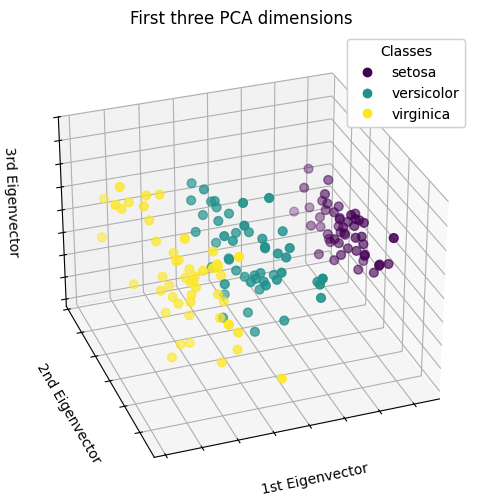

In [3]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(iris.data)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

In [ ]:
import numpy as np
x = [np.random.rand(15), np.random.rand(15)]
#RANDOM INPUT : Example input
%matplotlib inline


import qiskit
from qiskit import QuantumCircuit

from qiskit.compiler import transpile
from qiskit.primitives import Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt

def classical_pca(x):
    """Classical PCA: Computes covariance matrix and eigenvalues"""
    x = np.array(x)
    
    # Center and normalize the data
    x[0] -= np.mean(x[0])
    x[1] -= np.mean(x[1])
    x[0] /= np.linalg.norm(x[0])
    x[1] /= np.linalg.norm(x[1])

    # Compute covariance matrix
    m = np.cov(x)  # Already unbiased
    print("Covariance Matrix:\n", m)
   
    # Compute classical eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(m)
    print(f"Eigenvalues (Classical PCA): {eigvals}")
    return eigvals, eigvecs
   


print(classical_pca(x))


